# K-Meanswith Random Restart and K-Means++

1. **Reading** a dataset from a text file.
2. Implementing **K-Means** .
3. Performing **Random Restart** to pick the best run based on a chosen metric.
4. Using **WCSS** (Within-Cluster Sum of Squares) as the first metric.
5. Using a **second metric** (in this example, we use a simplified **between-cluster distance** measure).
6. Implementing and comparing to **K-Means++** initialization.

In [5]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import sys

## 1. Reading the dataset

In [6]:
def load_data(filename):
    """
    Loads 2D data from a text file, where each line contains two float values (x, y) separated by whitespace.
    Returns a list of tuples [(x1, y1), (x2, y2), ...].
    """
    data = []
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            x_str, y_str = line.split()
            x_val = float(x_str)
            y_val = float(y_str)
            data.append((x_val, y_val))
    return data

## 2. Distance helper
We'll use Euclidean distance as a helper.


In [7]:
def euclidean_distance(p1, p2):
    """
    Returns the Euclidean distance between two points p1=(x1, y1) and p2=(x2, y2).
    """
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

## 3. Random Initialization
We pick K random points from the data as initial centroids.


In [8]:
def initialize_centroids_random(data, K):
    """
    Randomly pick K distinct points from the dataset as centroids.
    data: list of (x, y)
    K: number of clusters
    """
    return random.sample(data, K)

## 4. K-Means++ Initialization
We'll do the basic K-Means++:
1. Pick one centroid uniformly at random from the data.
2. For each data point, compute distance squared to the nearest already chosen centroid.
3. Pick a new data point at random, weighted by that distance.
4. Repeat until K centroids are chosen.


In [9]:
def initialize_centroids_kmeans_plus_plus(data, K):
    """
    K-Means++ initialization for K centroids.
    data: list of (x, y)
    K: number of clusters
    """
    centroids = []
    # 1) Choose the first centroid randomly.
    centroids.append(random.choice(data))

    while len(centroids) < K:
        # distances^2 for each data point to its nearest centroid
        dist_sq = []
        for point in data:
            d = min(euclidean_distance(point, c) for c in centroids)
            dist_sq.append(d**2)

        # Weighted random choice
        total = sum(dist_sq)
        r = random.random() * total
        cumulative = 0.0
        for point, d_sq in zip(data, dist_sq):
            cumulative += d_sq
            if cumulative >= r:
                centroids.append(point)
                break
    return centroids

## 5. Assign points to clusters
Given a list of points and a list of centroids, we find the nearest centroid for each point.


In [10]:
def assign_clusters(data, centroids):
    """
    Assign each data point to the closest centroid.
    Returns a list of cluster indices corresponding to the data list.
    data: list of (x, y)
    centroids: list of (cx, cy)
    """
    assignments = []
    for point in data:
        distances = [euclidean_distance(point, c) for c in centroids]
        min_dist = min(distances)
        cluster_idx = distances.index(min_dist)
        assignments.append(cluster_idx)
    return assignments

## 6. Recompute centroids
After assigning clusters, we average the points in each cluster to get a new centroid.


In [11]:
def recompute_centroids(data, assignments, K):
    """
    Recompute centroids as the mean of the assigned data points.
    data: list of (x, y)
    assignments: list of cluster indices for each data point
    K: number of clusters
    """
    cluster_sums = [(0.0, 0.0)] * K
    cluster_counts = [0] * K

    sums_arrays = [[0.0, 0.0] for _ in range(K)]

    for (point, c_idx) in zip(data, assignments):
        sums_arrays[c_idx][0] += point[0]
        sums_arrays[c_idx][1] += point[1]
        cluster_counts[c_idx] += 1

    new_centroids = []
    for k in range(K):
        if cluster_counts[k] == 0:
            # If no points assigned, just keep it the same 
            new_centroids.append((sums_arrays[k][0], sums_arrays[k][1]))
        else:
            cx = sums_arrays[k][0] / cluster_counts[k]
            cy = sums_arrays[k][1] / cluster_counts[k]
            new_centroids.append((cx, cy))
    return new_centroids

## 7. WCSS (Within-Cluster Sum of Squares)
One metric we'll use to evaluate the quality of a clustering is the sum of squared distances from each point to its cluster's centroid.


In [12]:
def wcss(data, assignments, centroids):
    """
    Compute Within-Cluster Sum of Squares (WCSS).
    data: list of (x, y)
    assignments: cluster index for each data point
    centroids: (cx, cy)
    """
    total = 0.0
    for (point, c_idx) in zip(data, assignments):
        dist = euclidean_distance(point, centroids[c_idx])
        total += dist**2
    return total

## 8. A second metric (Between-Cluster Distance)
We'll define a simple measure of the average distance between cluster centroids. The bigger, the better.
We'll just average pairwise distances among the centroids.


In [13]:
def between_cluster_distance(centroids):
    """
    Compute average pairwise distance among all centroids.
    The bigger this is, the more 'spread out' the clusters are from each other.
    """
    K = len(centroids)
    if K < 2:
        return 0.0
    dist_sum = 0.0
    count = 0
    for i in range(K):
        for j in range(i+1, K):
            dist_sum += euclidean_distance(centroids[i], centroids[j])
            count += 1
    return dist_sum / count

## 9. The K-Means function
Given data, an initialization function, and a number of clusters, run the iterative K-Means until convergence.


In [14]:
def kmeans(data, K, init_func, max_iter=100, tolerance=1e-4):
    """
    Run K-Means given an init function to pick centroids.
    data: list of (x, y)
    K: number of clusters
    init_func: function that takes (data, K) -> initial centroids
    max_iter: maximum number of iterations
    tolerance: if centroids move less than this, we stop early
    Returns (assignments, centroids) after convergence.
    """
    centroids = init_func(data, K)

    for _ in range(max_iter):
        assignments = assign_clusters(data, centroids)
        new_centroids = recompute_centroids(data, assignments, K)

        # measure centroid shift
        shift = 0.0
        for c_old, c_new in zip(centroids, new_centroids):
            shift += euclidean_distance(c_old, c_new)

        centroids = new_centroids

        if shift < tolerance:
            break

    assignments = assign_clusters(data, centroids)
    return assignments, centroids

## 10. A function to run K-Means with random restarts
We'll try multiple random initializations and pick the best solution.  
We use a combination of WCSS (we want it minimized) and between-cluster distance (we want it maximized).  
For the combination, we might do a simple approach: `score = wcss - alpha * bcd` or something.  
But let's just keep them separate and compare them lexicographically, or do a weighted sum.


In [15]:
def kmeans_random_restart(data, K, n_restarts=10, alpha=1.0):
    """
    Tries K-Means with random init multiple times.
    We define a combined score = WCSS + (some penalty) where we actually want to minimize WCSS, 
    but we also want to maximize between-cluster distance, so we can do:
    combined_score = WCSS - alpha * BCD.
    We'll pick the clustering that yields the smallest combined_score.
    Returns (best_assignments, best_centroids, best_wcss, best_bcd).
    """
    best_assignments = None
    best_centroids = None
    best_score = float('inf')
    best_wcss_val = None
    best_bcd_val = None

    for _ in range(n_restarts):
        assignments, centroids = kmeans(data, K, initialize_centroids_random)
        curr_wcss = wcss(data, assignments, centroids)
        curr_bcd = between_cluster_distance(centroids)
        combined_score = curr_wcss - alpha * curr_bcd

        if combined_score < best_score:
            best_score = combined_score
            best_assignments = assignments
            best_centroids = centroids
            best_wcss_val = curr_wcss
            best_bcd_val = curr_bcd

    return best_assignments, best_centroids, best_wcss_val, best_bcd_val

## 11. Putting it all together

In [1]:
def main():
    """
    Main demonstration function.
    """
    # For instance: filename='unbalance.txt', algorithm='kmeans', n_clusters=8.
    filename = 'unbalance.txt'  # or 'normal.txt'
    K = 8
    alpha = 1.0  # weighting for BCD in combined score
    random_restarts = 5

    # 1. Load data.
    data = load_data(filename)

    # 2. Random-restart K-Means.
    assignments_rr, centroids_rr, wcss_rr, bcd_rr = kmeans_random_restart(
        data, K, n_restarts=random_restarts, alpha=alpha)

    # 3. K-Means++ (single run, no random restarts in this example).
    assignments_pp, centroids_pp = kmeans(data, K, initialize_centroids_kmeans_plus_plus)
    wcss_pp = wcss(data, assignments_pp, centroids_pp)
    bcd_pp = between_cluster_distance(centroids_pp)

    print(f"Best from Random-Restart K-Means:")
    print(f"  WCSS = {wcss_rr:.3f}, BCD = {bcd_rr:.3f}")
    print(f"K-Means++ (single run):")
    print(f"  WCSS = {wcss_pp:.3f}, BCD = {bcd_pp:.3f}")

    # 4. Let's pick whichever has the best combined score for final plotting, 
    # or we can just show both.
    # We'll plot the random-restart solution.
    plot_clusters(data, assignments_rr, centroids_rr, title="K-Means Random-Restart (best)")
    plot_clusters(data, assignments_pp, centroids_pp, title="K-Means++")


## 12. Plot function
We'll write a helper to visualize the data in 2D, coloring by assigned cluster.


In [36]:
def plot_clusters(data, assignments, centroids, title="K-Means Clusters"):
    """
    Plots the clustered data with distinct colors for each cluster,
    and plots centroids as black 'X'.
    """
    K = len(centroids)
    # convert data to np arrays for easier slicing
    data_arr = np.array(data)
    # We'll pick a color map
    colors = plt.get_cmap("tab10", K)

    plt.figure(figsize=(8,6))
    for k in range(K):
        cluster_points = data_arr[[i for i,a in enumerate(assignments) if a == k]]
        if len(cluster_points) > 0:
            plt.scatter(cluster_points[:,0], cluster_points[:,1], c=[colors(k)], label=f"Cluster {k}")

    # plot centroids as well
    cen_arr = np.array(centroids)
    plt.scatter(cen_arr[:,0], cen_arr[:,1], marker='x', s=200, c='k', label='Centroids')
    plt.title(title)
    plt.legend()
    plt.show()


## 13. Run the main!
Now we call `main()`.
You can modify the defaults inside `main()` or pass real arguments if you want.


Best from Random-Restart K-Means:
  WCSS = 2171950066993.225, BCD = 105465.312
K-Means++ (single run):
  WCSS = 214492062847.683, BCD = 207903.875


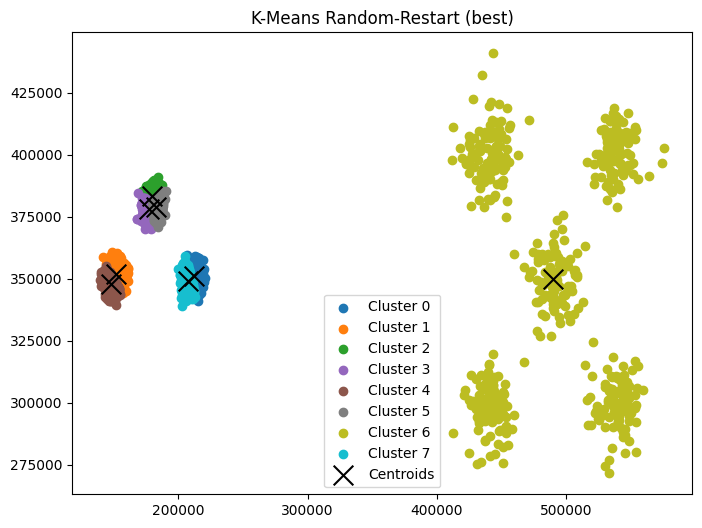

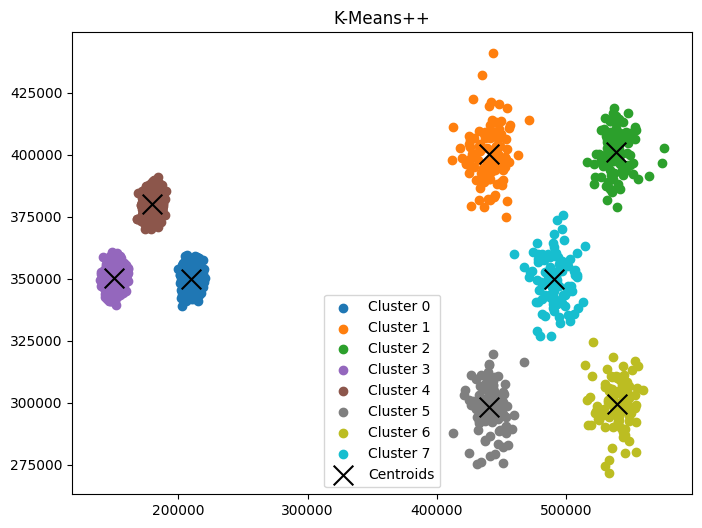

In [37]:
if __name__ == "__main__":
    # We can also override sys.argv or parse if needed.
    main()